## import data and clean it and save it

In [1]:
%load_ext autoreload
%autoreload 2

# import libraries

import sys
from src.extraction import load_raw, load_processed, FEATURE_COLUMNS
import pandas as pd
import numpy as np
from src.preprocessing import clean_data, log_transform, skewness_comparison
import matplotlib.pyplot as plt
import seaborn as sns

# import data and clean it

df_raw = load_raw()
df_clean = clean_data(df_raw)

## log transform

In [2]:
df_prepare_clustering = log_transform(df_clean)
df_prepare_clustering.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231
1,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725
2,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654
3,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000
4,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114


## histograms after the log, with skewness in the title

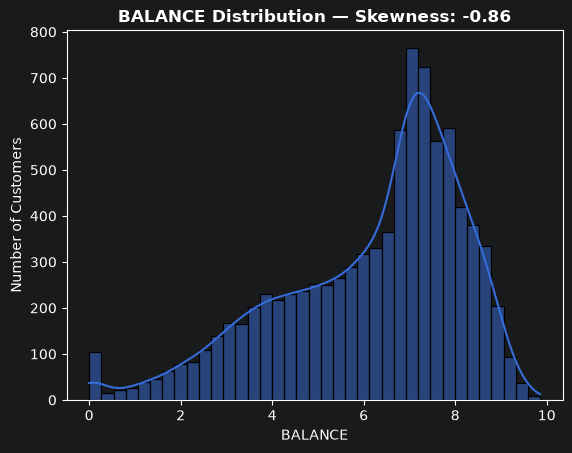

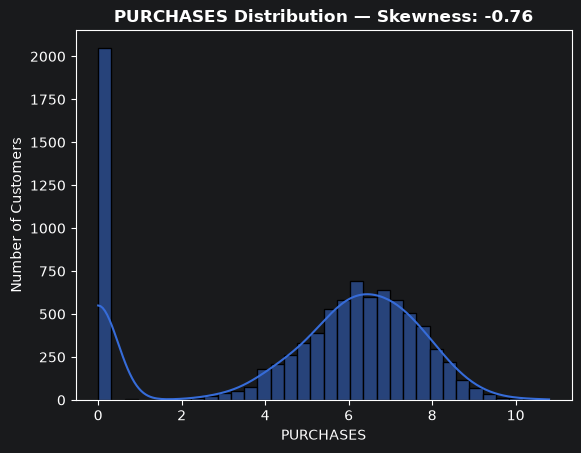

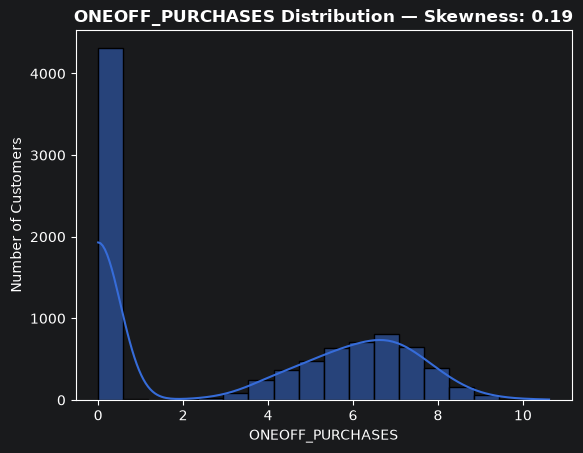

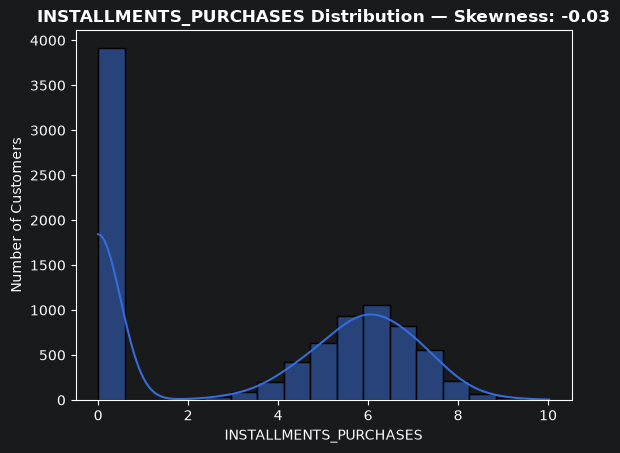

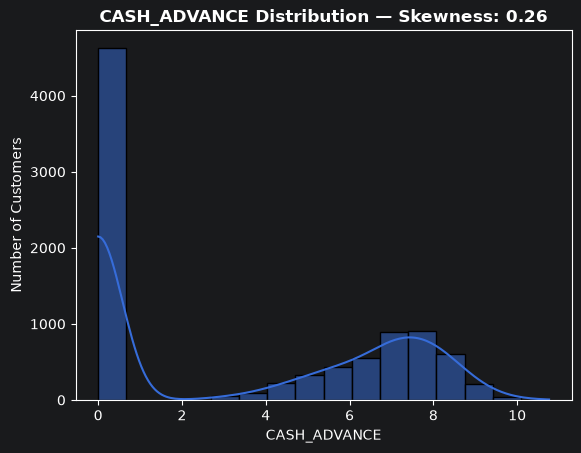

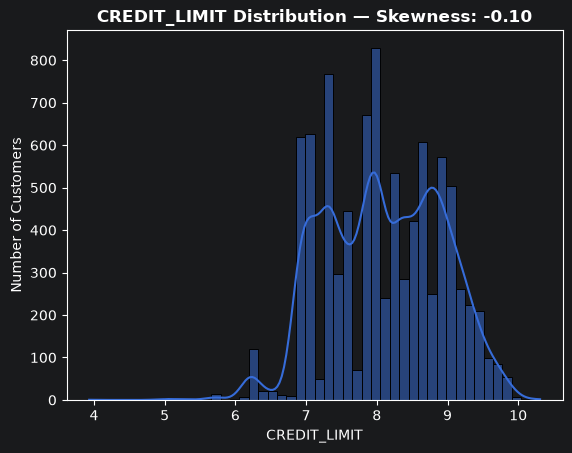

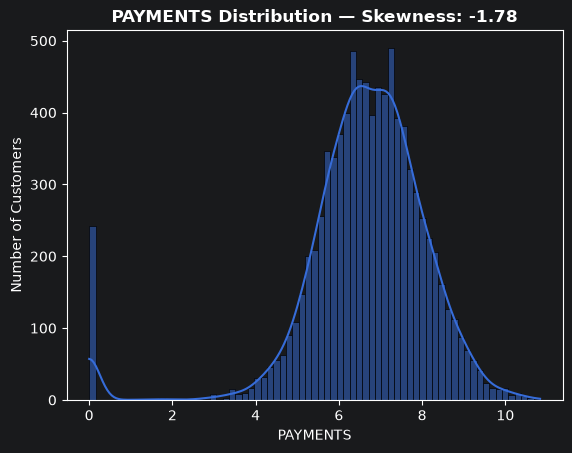

In [3]:
for column in FEATURE_COLUMNS: # the [1:] is for the first column that not numeric "CUST_ID"
    skewness = df_prepare_clustering[column].skew()

    sns.histplot(df_prepare_clustering[column], kde=True)

    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.title(
        f"{column} Distribution — Skewness: {skewness:.2f}",
        fontweight="bold"
    )

    plt.show()

## before/after skewness table

In [4]:
skew_table = skewness_comparison(df_clean, df_prepare_clustering)
skew_table

,skew_before,skew_after,abs_reduction,improved
ONEOFF_PURCHASES,10.04,0.19,9.86,True
PURCHASES,8.14,-0.76,7.38,True
INSTALLMENTS_PURCHASES,7.30,-0.03,7.27,True
PAYMENTS,5.91,-1.78,4.13,True
CASH_ADVANCE,5.17,0.26,4.90,True
BALANCE,2.39,-0.86,1.53,True
CREDIT_LIMIT,1.52,-0.10,1.42,True
